# Shirt-Present Training Convergence

Parses the TensorBoard event log for the selected `shirt_present` (UR5e-F140) training
run and plots training-reward and rollout success-metric convergence, for embedding into
the master thesis (Appendix A.5, `doc/Theses/master_thesis/thesis/chapters/appendices/A_5_TrainingMetrics.typ`).

Source run: `2026-07-04_15-21-09_ppo_torch_seed43`, checkpoint `agent_96000.pt`
(the checkpoint reported in the deterministic evaluation table, `tab:shirt_present_results`).
Note that the rates plotted here are *training-time rollout* metrics (stochastic policy,
logged every rollout), not the *deterministic evaluation* figures reported in the thesis
body — the two are expected to differ slightly and should not be conflated.

In [1]:
from pathlib import Path
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import matplotlib
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parents[1] if (Path.cwd() / ".." / "..").exists() else Path.cwd()
LOG_DIR = REPO_ROOT / "src/tensegrity_pick/logs/skrl/theses_logs/shirt_present/2026-07-04_15-21-09_ppo_torch_seed43"
OUT_SVG = REPO_ROOT / "doc/Theses/master_thesis/assets/figures/shirt_present/training_convergence.svg"
OUT_SVG.parent.mkdir(parents=True, exist_ok=True)

In [2]:
ea = EventAccumulator(str(LOG_DIR), size_guidance={"scalars": 0})
ea.Reload()

def series(tag):
    events = ea.Scalars(tag)
    return [e.step for e in events], [e.value for e in events]

steps_r, reward = series("Reward / Total reward (mean)")
steps_p, present = series("Metrics/present_rate")
steps_g, grasp = series("Metrics/grasp_rate")
steps_d, drop = series("Metrics/drop_rate")

print(f"reward: {len(steps_r)} points, {steps_r[0]}..{steps_r[-1]}, {reward[0]:.2f} -> {reward[-1]:.2f}")
print(f"present_rate final: {present[-1]:.3f}, grasp_rate final: {grasp[-1]:.3f}, drop_rate final: {drop[-1]:.4f}")

reward: 425 points, 600..96000, 0.95 -> 375.61
present_rate final: 1.000, grasp_rate final: 1.000, drop_rate final: 0.0003


wrote /Users/georg/Projects/studentische-arbeiten/doc/Theses/master_thesis/assets/figures/shirt_present/training_convergence.svg


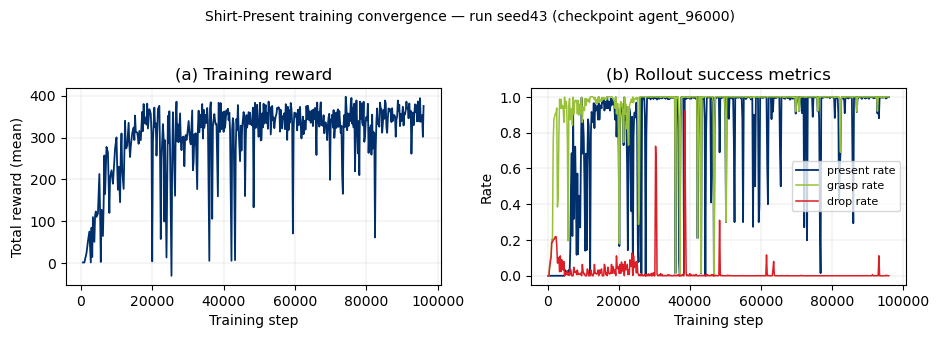

In [3]:
# FAPS palette (shared/formatting/colors.typ)
FAU_BLAU = "#002f6c"
FAPS_GRUEN = "#97c139"
ECHTROT = "#dc1e26"

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))

ax = axes[0]
ax.plot(steps_r, reward, color=FAU_BLAU, linewidth=1.3)
ax.set_xlabel("Training step")
ax.set_ylabel("Total reward (mean)")
ax.set_title("(a) Training reward")
ax.grid(True, linewidth=0.3, alpha=0.6)

ax = axes[1]
ax.plot(steps_p, present, color=FAU_BLAU, linewidth=1.3, label="present rate")
ax.plot(steps_g, grasp, color=FAPS_GRUEN, linewidth=1.1, label="grasp rate")
ax.plot(steps_d, drop, color=ECHTROT, linewidth=1.1, label="drop rate")
ax.set_xlabel("Training step")
ax.set_ylabel("Rate")
ax.set_ylim(-0.05, 1.05)
ax.set_title("(b) Rollout success metrics")
ax.legend(fontsize=8, loc="center right")
ax.grid(True, linewidth=0.3, alpha=0.6)

fig.suptitle(
    "Shirt-Present training convergence \u2014 run seed43 (checkpoint agent_96000)",
    fontsize=10,
)
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(OUT_SVG, format="svg")
print("wrote", OUT_SVG)